# Importing Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score, recall_score, confusion_matrix, f1_score, roc_curve,auc
from imblearn.over_sampling import RandomOverSampler
import warnings
from sklearn.exceptions import FitFailedWarning
warnings.simplefilter('ignore', FitFailedWarning)

# Importing Dataset

In [2]:
# The file path with forward slashes is recommended for stability
file_path = "C:/Users/Anjali Singh/Downloads/Employee_Attrition_Prediction-main/WA_Fn-UseC_-HR-Employee-Attrition.csv"

# Load the dataset using the pyarrow engine for faster performance
df = pd.read_csv(file_path, engine='pyarrow')

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# No Missing Values

In [4]:
df.isna().any().any()

np.False_

# Encoding Categorical Values

In [5]:
#Columns with string values
categorical_column = ['Attrition', 'BusinessTravel', 'Department','Gender', 'JobRole', 'MaritalStatus', 'OverTime','EducationField']
encoder=LabelEncoder()
df[categorical_column]=df[categorical_column].apply(encoder.fit_transform)

# Seperating into X and y

In [6]:
y=df['Attrition']
X=df.drop(['EmployeeCount','Attrition','EmployeeNumber','Over18','StandardHours'],axis=1)

In [7]:
ros = RandomOverSampler(random_state=42)
X, y = ros.fit_resample(X,y)

# Spliting into Train and Test Sets

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [26]:
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler
scaler = StandardScaler()

# Standardize the features
X_standardized = scaler.fit_transform(X)

# Hyper-parameter Tuning Using Grid Search CV

In [27]:
def tune_hyperparameters(model,X,y):
  param_grid = {"C":np.logspace(-3,3,7), "penalty":["l1","l2"],"solver":['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}
  grid_search = GridSearchCV(model,param_grid=param_grid)
  grid_search.fit(X,y)
  print("Best Params: ",grid_search.best_params_)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_standardized = scaler.fit_transform(X_train)
X_test_standardized = scaler.transform(X_test)

### With Standardization

In [30]:
tune_hyperparameters(LogisticRegression(max_iter=100000),X_train_standardized,y_train)

Best Params:  {'C': np.float64(0.1), 'penalty': 'l2', 'solver': 'lbfgs'}


C:\Users\Anjali Singh\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [       nan        nan 0.51390467        nan 0.51390467 0.73579626
 0.73579626 0.73116361 0.73579626 0.73579626        nan        nan
 0.68830527        nan 0.67730753 0.76592611 0.76592611 0.76245288
 0.76592611 0.76592611        nan        nan 0.76997403        nan
 0.7653397  0.76939935 0.76997906 0.76881964 0.76997906 0.76997906
        nan        nan 0.76245288        nan 0.76245288 0.76187317
 0.76187317 0.76187317 0.76187317 0.76187317        nan        nan
 0.76187317        nan 0.76187317 0.76187317 0.76129346 0.76187317
 0.76129346 0.76187317        nan        nan 0.76129346        nan
 0.76129346 0.76129346 0.76129346 0.76129346 0.76129346 0.76129346
        nan        nan 0.76129346        nan 0.76129346 0.76129346
 0.76129346 0.76129346 0.76129346 0.76129346]
  warnings.warn(


In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

### With Normalization

In [32]:
tune_hyperparameters(LogisticRegression(max_iter=100000),X_train_normalized,y_train)

Best Params:  {'C': np.float64(1.0), 'penalty': 'l2', 'solver': 'saga'}


C:\Users\Anjali Singh\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [       nan        nan 0.51390467        nan 0.50868727 0.6917651
 0.6917651  0.7074156  0.6917651  0.6917651         nan        nan
 0.62745246        nan 0.62745246 0.7491296  0.7491296  0.74449527
 0.7491296  0.7491296         nan        nan 0.7392829         nan
 0.74043227 0.76129011 0.76129011 0.75491665 0.76129011 0.76129011
        nan        nan 0.76649912        nan 0.769396   0.76997571
 0.76997571 0.76592611 0.76997571 0.77055542        nan        nan
 0.76245288        nan 0.76187317 0.76245288 0.76303259 0.76245288
 0.76245288 0.76245288        nan        nan 0.76129346        nan
 0.76129346 0.76187317 0.76129346 0.76129346 0.76187317 0.76187317
        nan        nan 0.76129346        nan 0.76129346 0.76187317
 0.76187317 0.76129346 0.76129346 0.76129346]
  warnings.warn(


# Performing Logistic Regression

In [35]:
def train_predict_evaluate(model,X_train,y_train,X_test):
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)

  print("Accuracy: ",accuracy_score(y_test,y_pred))
  print("Precision: ",precision_score(y_test,y_pred))
  print("Recall: ",recall_score(y_test,y_pred))
  print("F1 Score: ",f1_score(y_test,y_pred))
  print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

  
  fpr,tpr,thresholds = roc_curve(y_test,y_pred)
  plt.plot(fpr, tpr,color='green',label='ROC curve (area = %0.2f)' % auc(fpr,tpr))
  plt.plot([0, 1], [0, 1], color='orange', linestyle='--')
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve")
  plt.legend(loc="lower right")
  plt.show()

### Without scaling

C:\Users\Anjali Singh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 12977 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy:  0.7554054054054054
Precision:  0.7737789203084833
Recall:  0.7639593908629442
F1 Score:  0.768837803320562
Confusion Matrix:
 [[258  88]
 [ 93 301]]


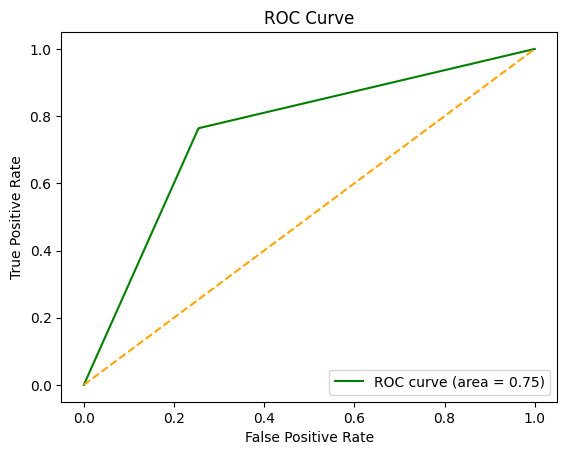

In [36]:
train_predict_evaluate(LogisticRegression(max_iter=100000),X_train,y_train,X_test)

### With Standardization

Accuracy:  0.754054054054054
Precision:  0.7717948717948718
Recall:  0.7639593908629442
F1 Score:  0.7678571428571429
Confusion Matrix:
 [[257  89]
 [ 93 301]]


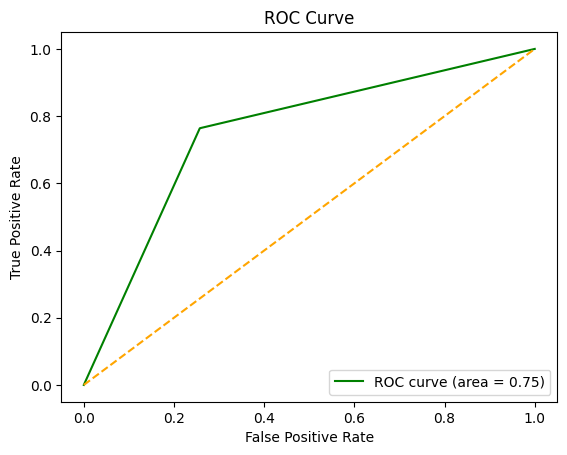

In [37]:
train_predict_evaluate(LogisticRegression(max_iter=100000,C=0.1,penalty='l2',solver='newton-cg'),X_train_standardized,y_train,X_test_standardized)

### With Normalization

Accuracy:  0.7594594594594595
Precision:  0.7783505154639175
Recall:  0.766497461928934
F1 Score:  0.7723785166240409
Confusion Matrix:
 [[260  86]
 [ 92 302]]


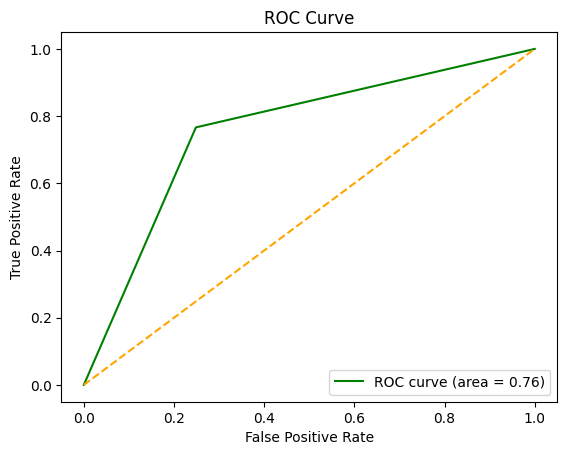

In [39]:
train_predict_evaluate(LogisticRegression(max_iter=100000,C=1.0,penalty='l2',solver='saga'),X_train_normalized,y_train,X_test_normalized)

# K-Fold Cross Validation

In [40]:
def cross_validation(model,X,y):
  scores = cross_validate(model, X, y, cv=5,scoring=('accuracy','precision','recall','f1'))

  metrics = []
  metrics.append(np.mean(scores['test_accuracy']))
  metrics.append(np.mean(scores['test_precision']))
  metrics.append(np.mean(scores['test_recall']))
  metrics.append(np.mean(scores['test_f1']))

  print("Accuracy: ",metrics[0])
  print("Precision: ",metrics[1])
  print("Recall: ",metrics[2])
  print("F1 Score: ",metrics[3])

  return metrics

In [41]:
metrics = []

### Without Scaling

In [42]:
metrics.append(cross_validation(LogisticRegression(max_iter=100000),X,y))

C:\Users\Anjali Singh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 12950 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Anjali Singh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 12892 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Accuracy:  0.7615474948879454
Precision:  0.7549342425367662
Recall:  0.7761594417563609
F1 Score:  0.7650613065679605


C:\Users\Anjali Singh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 12975 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### With Standardization

In [43]:
metrics.append(cross_validation(LogisticRegression(max_iter=100000,C=0.1,penalty='l2',solver='newton-cg'),X_standardized,y))

Accuracy:  0.769254584424863
Precision:  0.7585396295111104
Recall:  0.7915769724498866
F1 Score:  0.7742307533984836


In [45]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

### With Normalization

In [46]:
metrics.append(cross_validation(LogisticRegression(max_iter=100000,C=1.0,penalty='l2',solver='saga'),X_normalized,y))

Accuracy:  0.7647953946341903
Precision:  0.7543334486556486
Recall:  0.7875316809848261
F1 Score:  0.7700579417845361


# Performance and Comparison Plots

In [47]:
mdf = pd.DataFrame(metrics,columns=["Accuracy","Precision","Recall","F1 Score"],index=["Without Scaling","With Standardization","With Normalization"])
mdf.head()

,Accuracy,Precision,Recall,F1 Score
Without Scaling,0.761547,0.754934,0.776159,0.765061
With Standardization,0.769255,0.758540,0.791577,0.774231
With Normalization,0.764795,0.754333,0.787532,0.770058


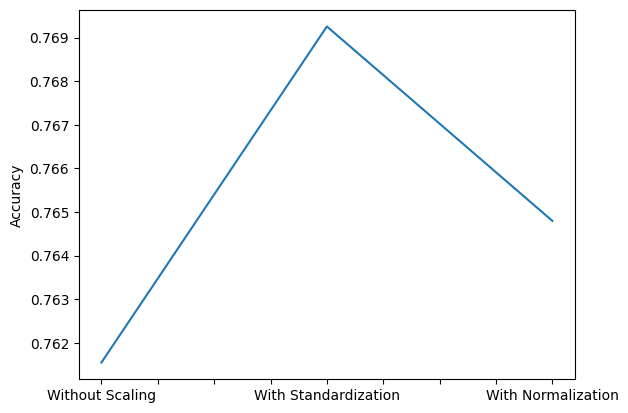

In [48]:
mdf['Accuracy'].plot()
plt.ylabel("Accuracy")
plt.show()

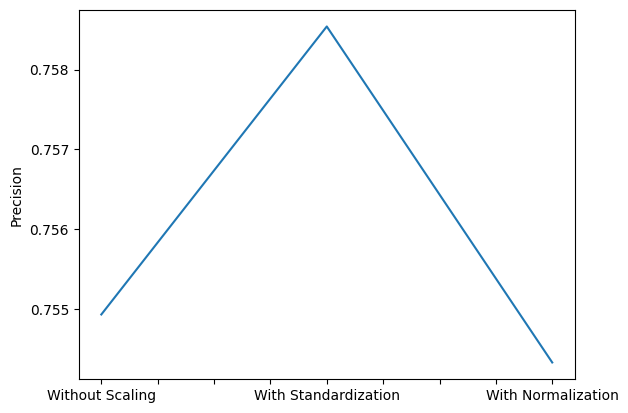

In [49]:
mdf['Precision'].plot()
plt.ylabel("Precision")
plt.show()

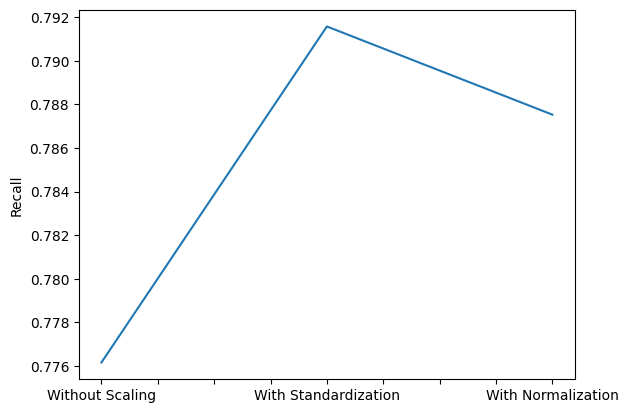

In [50]:
mdf['Recall'].plot()
plt.ylabel("Recall")
plt.show()

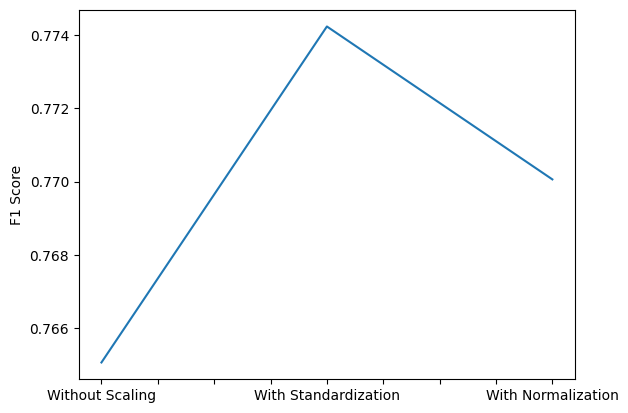

In [51]:
mdf['F1 Score'].plot()
plt.ylabel("F1 Score")
plt.show()